# CH 6 : Explanations for Out-of-Sample Deterioration — Old and New

## Objectif pédagogique

Ce notebook explique pourquoi une stratégie qui semble excellente en **backtest in-sample** peut se dégrader fortement en **out-of-sample** ou en réel.

L’idée centrale n’est pas forcément que le marché a changé.

L’idée centrale est plus subtile :

> Une stratégie sélectionnée parce qu’elle est la meilleure parmi beaucoup de candidates est souvent celle qui a reçu la plus grosse dose de chance dans le backtest.

En réel, cette chance ne se répète pas. La performance revient donc vers son niveau réel.


## Le problème en une phrase

Quand tu testes une seule règle, le hasard peut la rendre meilleure ou pire que sa vraie valeur.

Mais quand tu testes des centaines de règles, puis que tu choisis uniquement la meilleure, tu ne choisis pas seulement une règle.

Tu choisis aussi une **anomalie statistique favorable**.

> **Sélectionner le meilleur backtest**, c’est souvent sélectionner le backtest le plus chanceux.


## In-sample vs out-of-sample

| Terme | Signification | Rôle dans EBTA |
|---|---:|---|
| **In-sample** | Données utilisées pour chercher, tester, ajuster ou choisir la règle | Zone dangereuse, car contaminée par la sélection |
| **Out-of-sample** | Données jamais utilisées pour choisir la règle | Test plus honnête de la performance réelle |
| **Détérioration OOS** | Chute de performance après sélection | Souvent retour à la vraie espérance |

Le piège vient du fait que le backtest **in-sample** n’est pas seulement une mesure.

Il devient un outil de sélection.

Et dès qu’il y a sélection, il y a risque de **biais de minage de données**.


## L’explication classique : le marché aurait changé

Beaucoup de traders expliquent une chute de performance par une phrase simple :

> “Le marché a changé.”

Parfois, c’est vrai.

Mais Aronson pousse à être plus rigoureux : si toutes les stratégies chutent presque toujours après leur découverte, il faut chercher une cause systématique.

Le changement de marché peut arriver, mais il ne devrait pas frapper exactement au moment où le trader passe du laboratoire au réel avec une régularité quasi magique.

> Le marché n’est pas forcément diabolique. Il est surtout bruyant.


## L’explication EBTA : hasard + sélection

La dégradation out-of-sample vient souvent de deux forces qui travaillent ensemble.

### 1. Le hasard

Dans un échantillon historique fini, certaines règles auront de bons résultats par pure coïncidence.

Même si elles n’ont aucun pouvoir prédictif réel.

### 2. La sélection

Le trader choisit la règle qui a le meilleur résultat historique.

Mais cette règle est probablement celle qui a bénéficié du plus grand boost aléatoire.

Donc le backtest de la meilleure règle contient deux composantes :

$$
\text{Performance backtest} = \text{Talent réel} + \text{Chance in-sample}
$$

En out-of-sample, la chance in-sample ne se répète pas :

$$
\text{Performance OOS} \approx \text{Talent réel}
$$

> La chute n’est pas forcément une perte de talent. C’est souvent la disparition d’une prime de chance.


## Analogie simple : le gagnant de la loterie

Imagine que tu observes 1 000 personnes qui jouent à pile ou face.

Tu sélectionnes celle qui a obtenu la meilleure série de gains.

Puis tu conclus :

> “Cette personne a un talent spécial pour prédire pile ou face.”

Mais en réalité, tu as surtout sélectionné la personne la plus chanceuse de l’échantillon.

Quand elle rejoue demain, elle redevient normale.

C’est exactement ce qui arrive quand un trader teste 1 000 variantes de stratégie et sélectionne la meilleure courbe d’equity.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)


## Simulation 1 — Une seule règle sans talent

On commence avec une seule règle qui n’a aucun edge réel.

Son rendement moyen réel est donc :

$$
\mu = 0
$$

Mais sur un échantillon fini, elle peut afficher un profit positif ou négatif par hasard.


In [20]:
# Une seule règle sans talent réel
n_days = 252
true_mean = 0.0
volatility = 0.01

returns_one_rule = np.random.normal(loc=true_mean, scale=volatility, size=n_days)
mean_one_rule = returns_one_rule.mean()
annualized_one_rule = mean_one_rule * 252

print(f"Moyenne quotidienne observée : {mean_one_rule:.5f}")
print(f"Performance annualisée observée : {annualized_one_rule:.2%}")


Moyenne quotidienne observée : 0.00073
Performance annualisée observée : 18.51%


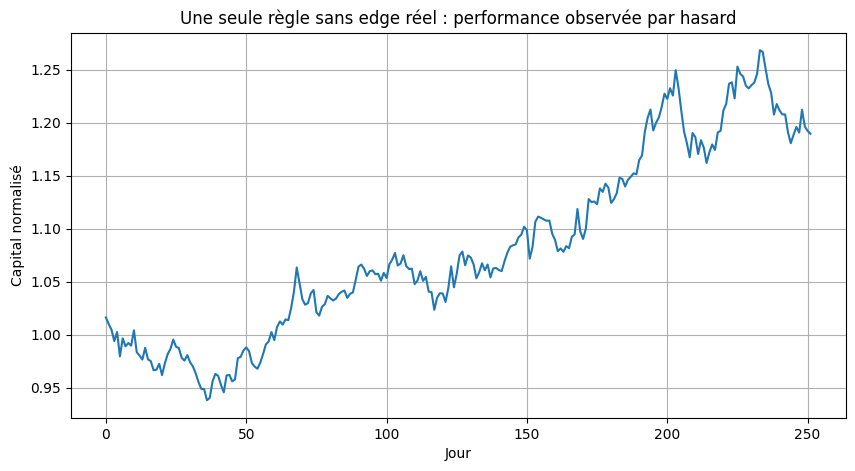

In [21]:
equity_one_rule = (1 + returns_one_rule).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(equity_one_rule)
plt.title("Une seule règle sans edge réel : performance observée par hasard")
plt.xlabel("Jour")
plt.ylabel("Capital normalisé")
plt.grid(True)
plt.show()


## Lecture EBTA de la simulation 1

Avec une seule règle, le hasard peut donner un résultat positif ou négatif.

Mais il n’y a pas encore de grand problème de sélection.

Le vrai danger commence quand on teste beaucoup de règles et qu’on garde uniquement la meilleure.


## Simulation 2 — Tester 1 000 règles sans talent et choisir la meilleure

Maintenant, on simule 1 000 règles.

Toutes ont une vraie espérance nulle :

$$
\mu_1 = \mu_2 = \dots = \mu_{1000} = 0
$$

Aucune règle n’a de talent.

Mais on va choisir celle qui a le meilleur backtest **in-sample**.


In [22]:
n_rules = 1000
n_days_is = 252
n_days_oos = 252

# In-sample : toutes les règles sont sans talent, mais avec du bruit
returns_is = np.random.normal(loc=0.0, scale=volatility, size=(n_rules, n_days_is))
mean_is = returns_is.mean(axis=1)
annualized_is = mean_is * 252

best_rule_index = np.argmax(annualized_is)
best_is_perf = annualized_is[best_rule_index]

print(f"Nombre de règles testées : {n_rules}")
print(f"Meilleure performance annualisée in-sample : {best_is_perf:.2%}")
print(f"Index de la règle sélectionnée : {best_rule_index}")


Nombre de règles testées : 1000
Meilleure performance annualisée in-sample : 53.70%
Index de la règle sélectionnée : 608


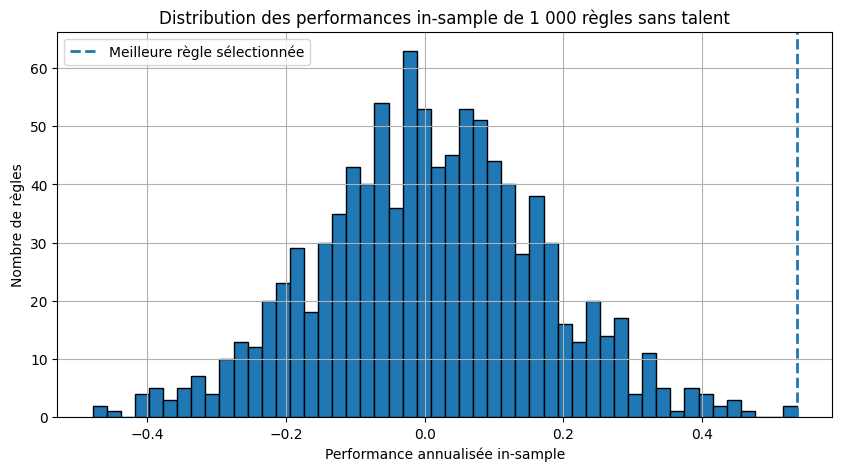

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(annualized_is, bins=50, edgecolor="black")
plt.axvline(best_is_perf, linestyle="--", linewidth=2, label="Meilleure règle sélectionnée")
plt.title("Distribution des performances in-sample de 1 000 règles sans talent")
plt.xlabel("Performance annualisée in-sample")
plt.ylabel("Nombre de règles")
plt.legend()
plt.grid(True)
plt.show()


## Ce que montre l’histogramme

Même si toutes les règles ont une vraie espérance de zéro, certaines semblent excellentes en backtest.

Pourquoi ?

Parce que dans 1 000 essais, il est presque inévitable qu’une règle tombe par hasard sur une combinaison très favorable.

La meilleure règle du groupe n’est donc pas forcément la plus talentueuse.

Elle peut simplement être la plus chanceuse.

> **Eurêka :** plus je teste de règles, plus j’augmente mes chances de trouver une fausse pépite.


## Simulation 3 — Que devient la meilleure règle en out-of-sample ?

On prend la règle sélectionnée comme “meilleure”.

Puis on la teste sur une nouvelle période qui n’a pas servi à la choisir.

Comme cette règle n’a aucun edge réel dans notre simulation, sa performance devrait revenir vers zéro.


In [24]:
# Out-of-sample : la règle sélectionnée est toujours sans talent réel
returns_oos_best = np.random.normal(loc=0.0, scale=volatility, size=n_days_oos)
oos_perf = returns_oos_best.mean() * 252

equity_is_best = (1 + returns_is[best_rule_index]).cumprod()
equity_oos_best = equity_is_best[-1] * (1 + returns_oos_best).cumprod()

print(f"Performance annualisée in-sample de la règle choisie : {best_is_perf:.2%}")
print(f"Performance annualisée out-of-sample de la même règle : {oos_perf:.2%}")
print(f"Détérioration estimée : {(oos_perf - best_is_perf):.2%}")


Performance annualisée in-sample de la règle choisie : 53.70%
Performance annualisée out-of-sample de la même règle : 4.17%
Détérioration estimée : -49.53%


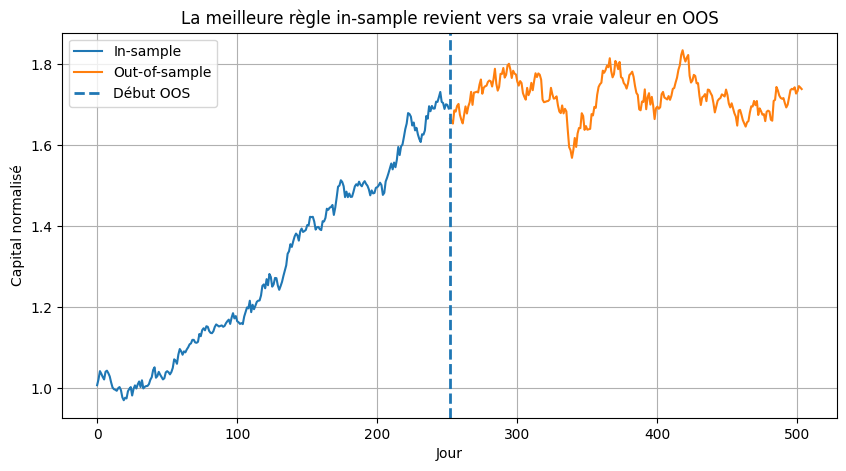

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(range(n_days_is), equity_is_best, label="In-sample")
plt.plot(range(n_days_is, n_days_is + n_days_oos), equity_oos_best, label="Out-of-sample")
plt.axvline(n_days_is, linestyle="--", linewidth=2, label="Début OOS")
plt.title("La meilleure règle in-sample revient vers sa vraie valeur en OOS")
plt.xlabel("Jour")
plt.ylabel("Capital normalisé")
plt.legend()
plt.grid(True)
plt.show()


## Lecture EBTA de la simulation 3

La règle ne “meurt” pas forcément.

Elle revient simplement à son niveau réel.

Dans notre exemple, son niveau réel est zéro.

La performance in-sample était artificiellement haute parce qu’elle contenait une **prime de chance**.

$$
\text{Détérioration OOS} \approx -\text{Prime de chance in-sample}
$$

> La chute n’est pas le scandale. Le scandale était l’excès d’optimisme du backtest.


## Simulation 4 — Plus tu testes de règles, plus le meilleur backtest devient trompeur

On va répéter l’expérience avec différents nombres de règles candidates.

L’objectif est de voir ce qui arrive à la meilleure performance in-sample quand le nombre de règles testées augmente.


In [26]:
def simulate_best_in_sample(n_rules, n_days=252, volatility=0.01, seed=None):
    if seed is not None:
        np.random.seed(seed)
    returns = np.random.normal(loc=0.0, scale=volatility, size=(n_rules, n_days))
    annualized = returns.mean(axis=1) * 252
    return annualized.max()

rule_counts = [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
repetitions = 200

rows = []
for n in rule_counts:
    best_values = [simulate_best_in_sample(n) for _ in range(repetitions)]
    rows.append({
        "nombre_de_regles": n,
        "meilleur_backtest_moyen": np.mean(best_values),
        "meilleur_backtest_median": np.median(best_values),
        "percentile_95": np.percentile(best_values, 95),
    })

summary = pd.DataFrame(rows)
summary


,nombre_de_regles,meilleur_backtest_moyen,meilleur_backtest_median,percentile_95
0,1,-0.007214,0.007459,0.262929
1,5,0.181084,0.178166,0.357841
2,10,0.249255,0.243729,0.402746
3,25,0.306128,0.303888,0.434541
4,50,0.349012,0.341678,0.471038
5,100,0.396870,0.390234,0.510925
6,250,0.445463,0.438438,0.571469
7,500,0.471054,0.465421,0.588261
8,1000,0.506384,0.506084,0.614739
9,2500,0.559102,0.554526,0.654697


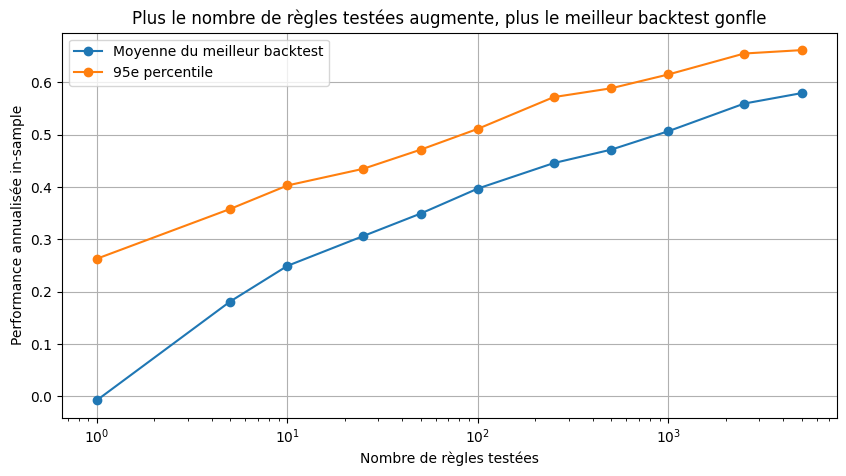

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(summary["nombre_de_regles"], summary["meilleur_backtest_moyen"], marker="o", label="Moyenne du meilleur backtest")
plt.plot(summary["nombre_de_regles"], summary["percentile_95"], marker="o", label="95e percentile")
plt.xscale("log")
plt.title("Plus le nombre de règles testées augmente, plus le meilleur backtest gonfle")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Performance annualisée in-sample")
plt.legend()
plt.grid(True)
plt.show()


## Interprétation de la simulation 4

Le graphique montre une idée fondamentale :

> Même avec zéro edge réel, le meilleur backtest devient de plus en plus impressionnant quand le nombre de règles testées augmente.

Ce n’est pas parce que le trader devient meilleur.

C’est parce que le laboratoire statistique devient plus dangereux.

Plus tu ouvres de portes, plus tu as de chances de tomber sur une porte qui cache un résultat chanceux.


## Le piège mental du trader

Le trader voit ceci :

$$
\text{Backtest exceptionnel} \Rightarrow \text{Stratégie exceptionnelle}
$$

Mais EBTA répond :

$$
\text{Backtest exceptionnel après sélection} \Rightarrow \text{Peut-être stratégie chanceuse}
$$

La différence est énorme.

Un backtest exceptionnel trouvé après beaucoup d’essais n’a pas la même valeur qu’un backtest exceptionnel obtenu avec une hypothèse pré-définie.


## Tableau de diagnostic EBTA

| Symptôme | Mauvaise interprétation | Lecture EBTA |
|---|---|---|
| Le backtest est magnifique | “J’ai trouvé un edge” | Peut-être un record de chance |
| L’OOS chute fortement | “Le marché a changé” | Retour vers l’espérance réelle |
| La meilleure règle est très au-dessus des autres | “Elle est spéciale” | Elle a peut-être reçu le plus gros boost aléatoire |
| Beaucoup de variantes ont été testées | “J’ai fait une recherche complète” | Risque élevé de data mining |
| La règle a été ajustée plusieurs fois | “Je l’ai optimisée” | L’OOS est probablement contaminé |


## Comment réduire le danger ?

### 1. Séparer strictement les données

Il faut une période **out-of-sample finale** qui n’a jamais servi à choisir ou modifier la règle.

Pas une seule fois.

### 2. Compter le nombre réel d’essais

Chaque variation de paramètre, filtre, condition ou marché testé augmente le risque de sélection chanceuse.

### 3. Réduire les attentes

Un backtest sélectionné doit être décoté.

Il faut retirer mentalement une **prime de chance**.

### 4. Utiliser des corrections statistiques

Dans le cadre EBTA, des méthodes comme le **White’s Reality Check** ou d’autres procédures de correction du data mining servent précisément à estimer ce que le hasard peut produire quand on teste beaucoup de règles.


## Mini-checklist avant de croire un backtest

Avant de risquer du capital, pose-toi ces questions :

- Combien de règles ou variantes ai-je réellement testées ?
- Ai-je choisi cette règle parce qu’elle était la meilleure du lot ?
- L’out-of-sample a-t-il été totalement préservé ?
- Ai-je modifié la stratégie après avoir vu les résultats OOS ?
- La performance reste-t-elle crédible après déduction d’une prime de chance ?
- La logique économique ou comportementale de l’edge est-elle claire ?

> Un backtest n’est pas une preuve. C’est une pièce à conviction qui doit survivre à une enquête statistique.


## L’Eurêka final

> Ta stratégie ne “meurt” pas forcément quand tu passes en réel.
>
> Elle révèle souvent ce qu’elle était déjà : beaucoup moins bonne que son backtest sélectionné.

La vraie leçon est brutale mais libératrice :

$$
\text{Performance réelle} \neq \text{Meilleur backtest trouvé}
$$

La performance réelle ressemble plutôt à ceci :

$$
\text{Performance réelle} \approx \text{Backtest sélectionné} - \text{Prime de chance} - \text{Coûts} - \text{Erreur d'exécution}
$$

C’est pour cela que l’EBTA ne cherche pas à admirer les belles courbes.

Elle cherche à savoir ce qu’il reste quand la chance, la sélection et l’optimisme ont été retirés.


## Exercice pratique

Modifie les paramètres suivants dans les cellules de simulation :

- `n_rules`
- `n_days_is`
- `volatility`
- `repetitions`

Puis observe :

1. comment le meilleur backtest augmente avec le nombre de règles ;
2. comment la performance out-of-sample revient vers zéro ;
3. comment la volatilité amplifie les faux espoirs.

Question clé :

> À partir de combien de variantes testées ton backtest commence-t-il à ressembler davantage à une loterie qu’à une preuve ?


## Annexe — Source fournie


### **CH 6 : EXPLANATIONS FOR OUT-OF-SAMPLE DETERIORATION: OLD AND NEW**

Cette section analyse les raisons pour lesquelles les stratégies de trading, si performantes en backtest (*in-sample*), s'effondrent presque systématiquement lorsqu'elles sont appliquées à de nouvelles données ou au trading réel (*out-of-sample*).

---

#### **Idées clés :**
*   **L'insuffisance de la variation aléatoire :** Si le hasard était seul responsable, la performance monterait aussi souvent qu'elle descendrait ; or, elle chute presque toujours.
*   **L'excuse des "dynamiques de marché" :** Blâmer un changement soudain du marché est statistiquement peu plausible.
*   **Le "Vilain" principal :** La détérioration est causée par la combinaison du hasard et de la logique de sélection (choisir le meilleur résultat).
*   **La chute de l'attente :** La dégradation n'est pas une perte de pouvoir prédictif, mais un retour à la réalité depuis un niveau de profit artificiellement gonflé par la chance.

---

#### **Référence :**
*Explanations for Out-of-Sample Deterioration: Old and New* (Pages 262–264).

---

#### **Citation Directe :**
« Out-of-sample performance deterioration of the best rule is most probably a fall from an unrealistically high expectation rather than an actual decline in the rule’s predictive power. » (Page 264).

---

#### **Vision Macro :**
L'enjeu est de briser le mythe du "marché qui a changé" pour masquer une mauvaise méthodologie. David Aronson explique que le trader est souvent victime de sa propre cupidité intellectuelle : en testant des centaines de règles, il finit par en trouver une dont les signaux coïncident par accident avec les fluctuations du marché. Le trader croit avoir découvert une loi du marché, alors qu'il a simplement déterré un "record de chance" qui, par définition, ne se répétera pas.

---

#### **Vision Micro :**

1.  **Réfutation des théories classiques :**
    *   **Variation Aléatoire :** Invalide, car elle n'explique pas le biais directionnel (la chute quasi constante).
    *   **Changement de Dynamique :** Implausible. Il serait "diabolique" que le marché change ses règles exactement au moment où le technicien quitte son laboratoire pour trader en réel.
    *   **Adoption Massive (Crowded Trades) :** Peu probable vu l'infinité de règles possibles ; la baisse de performance est souvent liée à la volatilité et non à l'usage de la règle.

2.  **L'explication EBTA (Le Biais de Minage de Données) :**
    *   **Composante 1 (Le Hasard) :** Dans n'importe quel échantillon, le hasard booste certaines règles et en plombe d'autres.
    *   **Composante 2 (La Sélection) :** Le data miner choisit la règle avec le profit maximum. Mathématiquement, il sélectionne donc la règle qui a bénéficié de la plus grande dose de chance.
    *   **Conséquence :** Une fois hors-échantillon, la chance "s'évapore" et la performance revient à son niveau réel (souvent proche de zéro), créant l'illusion d'une détérioration.

---

#### **Résumé Simplifié :**
Ta stratégie ne "meurt" pas quand tu commences à la trader ; elle n'a simplement jamais été aussi bonne que ce que le backtest prétendait. Tu as engagé le gagnant d'une loterie statistique en croyant qu'il avait un don pour prédire les numéros. En réel, il redevient un joueur normal et perd.

---

#### **Actions Concrètes :**
*   **Appliquer le Rasoir d'Ockham :** Avant d'accuser le marché, partez du principe que votre profit de backtest est un faux positif dû au minage de données.
*   **Réduire les attentes :** Déduisez systématiquement une "prime de chance" de vos profits de backtest avant de planifier votre capital.
*   **Isoler strictement le Out-of-Sample :** Utilisez une période de test finale qui n'a JAMAIS servi à ajuster les paramètres de la règle pour obtenir un estimateur sans biais.

---

#### **À retenir absolument :**
*   La performance chute car elle était **artificiellement haute**.
*   Le **marché n'est pas diabolique**, il est juste bruyant.
*   **Sélectionner le meilleur** = Sélectionner le plus chanceux.
*   La chance est une composante **non récurrente** de la performance.
*   Le biais de minage est le **"métal des fous"** de l'analyse technique.

J'ai terminé l'analyse de l'explication de la détérioration hors-échantillon selon le protocole EBTA.
```
